In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (1).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [5]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [6]:
import pandas as pd

df['Дата'] = pd.to_datetime(df['Дата'], format='%Y-%m-%d', errors='coerce')

In [7]:
df['Дата'].dtype
df.isna().sum()

Дата            0
Склад           0
Контрагент      0
Номенклатура    0
Количество      0
dtype: int64

Сгруппируйте данные по дате, посчитайте количество продаж

In [8]:
sales_by_date = (
    df.groupby('Дата', as_index=False)['Количество']
      .sum()
      .rename(columns={'Количество': 'Продажи'})
)

Вывести несколько первых строк сгруппированных данных

In [9]:
sales_by_date.head()

,Дата,Продажи
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

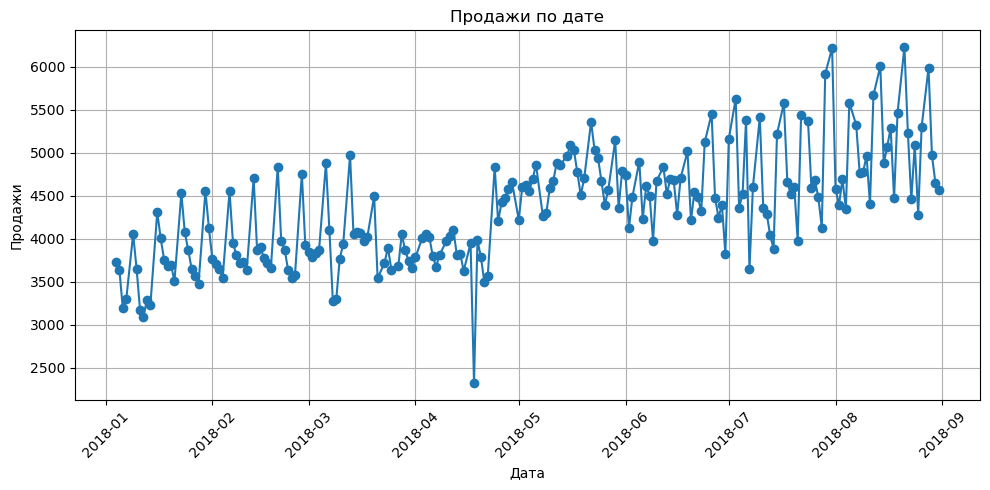

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(sales_by_date['Дата'], sales_by_date['Продажи'], marker='o', linestyle='-')
plt.title('Продажи по дате')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
на основе этого графика я могу понять, в какие дни продажи были высокие или низкие,
и на основании этого планировать закупки, акции или анализировать спрос.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
max_row = df[df['Количество'] == df['Количество'].max()]

print(max_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [14]:
# Приведение даты к datetime (если еще не сделано)
df['Дата'] = pd.to_datetime(df['Дата'])

# Добавляем день недели и месяц
df['День_недели'] = df['Дата'].dt.weekday  # понедельник=0, среда=2
df['Месяц'] = df['Дата'].dt.month

# Фильтруем: Склад 3, среда, июнь-июль-август
summer_wednesdays = df[
    (df['Склад'] == 3) &
    (df['День_недели'] == 2) &
    (df['Месяц'].isin([6,7,8]))
]


In [15]:
top_products = (
    summer_wednesdays.groupby('Номенклатура', as_index=False)['Количество']
    .sum()
    .sort_values(by='Количество', ascending=False)
)

In [16]:
# Топ-1 товар
top_product = top_products.iloc[0]

print("Топовый товар по продажам в среду летом на складе 3:")
print(top_product)

Топовый товар по продажам в среду летом на складе 3:
Номенклатура    product_1
Количество           2267
Name: 1, dtype: object


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [83]:
import pandas as pd
import matplotlib.pyplot as plt


In [86]:
# приводим дату
df['Дата'] = pd.to_datetime(df['Дата'])

# группируем по дате
grouped_df = (
    df
    .groupby('Дата', as_index=False)['Количество']
    .sum()
    .rename(columns={'Количество': 'Количество продаж'})
)

grouped_df.head()


,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


In [87]:
weather_raw = pd.read_csv(
    'weather.csv',
    sep=';',
    encoding='utf-8-sig'   # важно! убирает BOM
)

weather_raw.columns


Index(['Дата', 'T'], dtype='object')